# Bài tập

**Chương 8 - Giới thiệu học sâu cho thị giác máy tính**

Notebook này dùng để thực hành các nội dung quan trọng trong Chapter 8:

- Xây dựng **convnet/CNN** bằng Keras.
- Hiểu **Conv2D**, **filter/kernel**, **feature map**, **response map**.
- Hiểu vai trò của **MaxPooling2D**.
- Nhận diện và phân tích **overfitting** khi dữ liệu ít.
- Sử dụng **data augmentation** và **dropout**.
- Thực hành ý tưởng **pretrained model**, **feature extraction** và **fine-tuning**.

> Sinh viên hãy hoàn thiện các cell có ghi **TODO**, chạy notebook, lưu kết quả output, và trả lời câu hỏi phân tích bằng tiếng Việt.

## Yêu cầu nộp bài

1. Hoàn thiện tất cả phần **Bắt buộc**.
2. Chạy notebook để có output, biểu đồ và kết quả đánh giá.
3. Trả lời các câu hỏi phân tích trong các markdown cell.
4. Giữ nguyên tên file hoặc đổi theo mẫu giảng viên yêu cầu, ví dụ: `MSSV_HoTen_C8-BaiTap.ipynb`.

Phần pretrained/fine-tuning có thể được xem là bài nâng cao nếu máy không có GPU hoặc không tải được weights ImageNet.

## 0. Chuẩn bị môi trường

Không sửa cell này trừ khi thật sự cần thiết.

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Đặt True để chạy nhanh trên lớp. Đặt False nếu muốn kết quả ổn định hơn.
FAST_RUN = True

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

I0000 00:00:1781091041.578608   22586 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781091041.610974   22586 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781091042.392129   22586 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
def plot_history(history, title="Training history"):
    """Vẽ accuracy/loss cho train và validation."""
    metrics = history.history
    plt.figure(figsize=(11, 4))

    plt.subplot(1, 2, 1)
    plt.plot(metrics["accuracy"], "o-", label="Train")
    plt.plot(metrics["val_accuracy"], "o-", label="Validation")
    plt.title(title + " - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(metrics["loss"], "o-", label="Train")
    plt.plot(metrics["val_loss"], "o-", label="Validation")
    plt.title(title + " - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()


def show_images(images, labels=None, class_names=None, n=10, cmap=None):
    plt.figure(figsize=(10, 3))
    for i in range(n):
        plt.subplot(2, 5, i + 1)
        if images.shape[-1] == 1:
            plt.imshow(images[i, :, :, 0], cmap=cmap or "gray")
        else:
            plt.imshow(np.clip(images[i], 0, 1), cmap=cmap)
        if labels is not None:
            label = int(labels[i])
            title = class_names[label] if class_names else str(label)
            plt.title(title)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# Phần A - Convnet với MNIST

## Bài 1. Load dữ liệu và tiền xử lý MNIST

**Mục tiêu:** đưa ảnh MNIST về đúng format cho convnet.

Yêu cầu:

- Load dataset MNIST bằng `keras.datasets.mnist.load_data()`.
- Scale pixel từ `[0, 255]` về `[0, 1]`.
- Thêm chiều channel để input có shape **(28, 28, 1)**.
- Tạo tập validation từ training set.

x_train: (10000, 28, 28, 1)
x_val: (2000, 28, 28, 1)
test_images: (10000, 28, 28, 1)


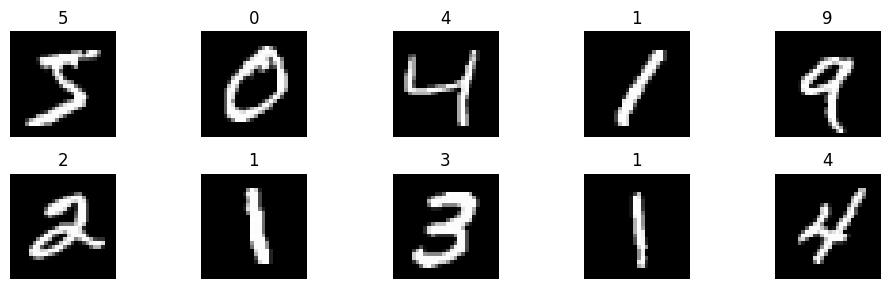

In [4]:
# TODO 1: Load MNIST
(train_images, train_labels), (test_images, test_labels) = keras.datasets.mnist.load_data()

# TODO 2: Chuyển kiểu dữ liệu sang float32 và scale về [0, 1]
train_images = train_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0

# TODO 3: Thêm chiều channel ở cuối để được shape (samples, 28, 28, 1)
train_images = np.expand_dims(train_images, axis=-1)
test_images = np.expand_dims(test_images, axis=-1)

# TODO 4: Tạo validation set
n_train = 10_000 if FAST_RUN else 50_000
n_val = 2_000 if FAST_RUN else 10_000

x_train = train_images[:n_train]
y_train = train_labels[:n_train]
x_val = train_images[n_train:n_train + n_val]
y_val = train_labels[n_train:n_train + n_val]

print("x_train:", x_train.shape)
print("x_val:", x_val.shape)
print("test_images:", test_images.shape)

show_images(x_train, y_train, n=10, cmap="gray")

### Trả lời Bài 1

1. Vì sao convnet cần input dạng `(height, width, channels)` thay vì vector 1D?
2. Với ảnh MNIST, tại sao `channels = 1`?
3. Nếu ảnh là RGB thì input shape của một ảnh 180 x 180 là gì?

**Trả lời tại đây:**

1. ConvNet cần input (height, width, channels) để giữ nguyên cấu trúc không gian của ảnh, giúp kernel học đặc trưng cục bộ hiệu quả.
2. Vì ảnh MNIST là ảnh xám (grayscale), mỗi pixel chỉ có một giá trị cường độ sáng.
3. Với ảnh RGB kích thước 180 × 180, input shape của một ảnh là (180, 180, 3).

## Bài 2. Xây dựng convnet MNIST

**Mục tiêu:** xây model tương tự ví dụ trong sách:

`Conv2D -> MaxPooling2D -> Conv2D -> MaxPooling2D -> Conv2D -> Flatten -> Dense`

Yêu cầu:

- Dùng ít nhất **3 lớp Conv2D**.
- Dùng ít nhất **2 lớp MaxPooling2D**.
- Output layer có **10 units** và activation **softmax**.
- Compile với `sparse_categorical_crossentropy`.

In [5]:
def build_mnist_convnet():
    inputs = keras.Input(shape=(28, 28, 1))

    # TODO: Hoàn thiện kiến trúc model
    x = layers.Conv2D(filters=32, kernel_size=3, activation="relu", name="conv_1")(inputs)
    x = layers.MaxPooling2D(pool_size=2, name="pool_1")(x)
    x = layers.Conv2D(filters=64, kernel_size=3, activation="relu", name="conv_2")(x)
    x = layers.MaxPooling2D(pool_size=2, name="pool_2")(x)
    x = layers.Conv2D(filters=128, kernel_size=3, activation="relu", name="conv_3")(x)
    x = layers.Flatten()(x)
    outputs = layers.Dense(10, activation="softmax")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    return model


mnist_convnet = build_mnist_convnet()
mnist_convnet.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
mnist_convnet.summary()

I0000 00:00:1781091053.733631   22586 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6207 MB memory:  -> device: 0, name: NVIDIA RTX A2000 8GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        11,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,202 (407.04 KB)

 Trainable params: 104,202 (407.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/2


I0000 00:00:1781091059.773622   32304 service.cc:153] XLA service 0x78c288030c70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781091059.773636   32304 service.cc:161]   StreamExecutor [0]: NVIDIA RTX A2000 8GB Laptop GPU, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1781091059.800332   32304 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781091059.900303   32304 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1781091059.909039   32304 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1092__.30


 59/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5248 - loss: 1.4224

I0000 00:00:1781091063.484881   32304 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


143/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6813 - loss: 0.9813

I0000 00:00:1781091064.053461   32303 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1092__.30


157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.8464 - loss: 0.4992 - val_accuracy: 0.8735 - val_loss: 0.4064
Epoch 2/2
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9589 - loss: 0.1406 - val_accuracy: 0.9145 - val_loss: 0.2496
MNIST test accuracy: 0.9379


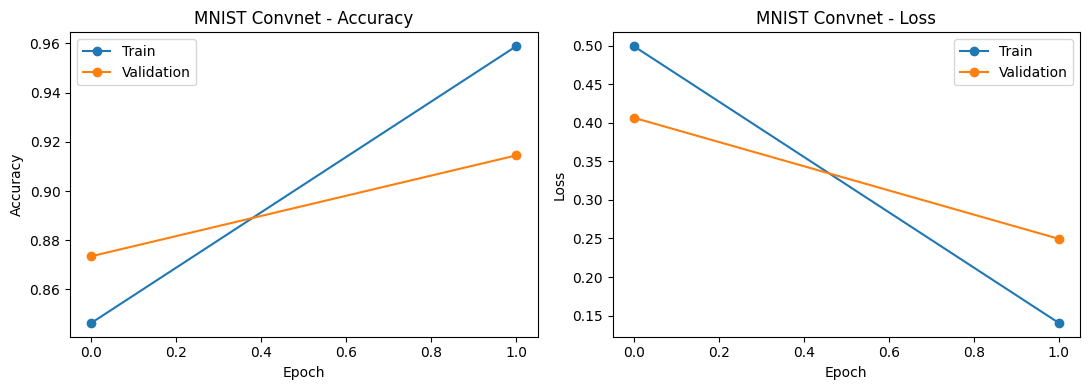

In [6]:
# TODO: Huấn luyện model
epochs = 2 if FAST_RUN else 5

history_mnist = mnist_convnet.fit(
    x_train,
    y_train,
    epochs=epochs,
    batch_size=64,
    validation_data=(x_val, y_val),
)

test_loss, test_acc = mnist_convnet.evaluate(test_images, test_labels, verbose=0)
print(f"MNIST test accuracy: {test_acc:.4f}")

plot_history(history_mnist, "MNIST Convnet")

### Trả lời Bài 2

1. Ghi lại test accuracy của convnet. 
2. Quan sát `model.summary()`: kích thước feature map thay đổi như thế nào sau Conv2D và MaxPooling2D?
3. Vì sao cần `Flatten()` trước khi đưa vào `Dense`?

**Trả lời tại đây:**

1. MNIST test accuracy: 0.9379
2. Sau Conv2D, kích thước không gian giảm nhẹ và số kênh tăng lên; sau MaxPooling2D, kích thước không gian giảm đi một nửa và số kênh giữ nguyên.
3. Cần Flatten() để chuyển tensor nhiều chiều của feature maps thành vector 1D, giúp các lớp Dense nhận dữ liệu đầu vào đúng định dạng.

## Bài 3. So sánh Dense model và Convnet

**Mục tiêu:** thấy vì sao convnet phù hợp hơn với ảnh.

Yêu cầu:

- Xây một Dense model đơn giản cho MNIST.
- So sánh số tham số và accuracy với convnet ở Bài 2.

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/2


I0000 00:00:1781092110.720371   32302 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_8729__.12


127/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7441 - loss: 0.9440

I0000 00:00:1781092112.106480   32302 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_8729__.12


157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8546 - loss: 0.5549 - val_accuracy: 0.8900 - val_loss: 0.3724
Epoch 2/2
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9230 - loss: 0.2770 - val_accuracy: 0.9100 - val_loss: 0.2999
Dense test accuracy: 0.9108


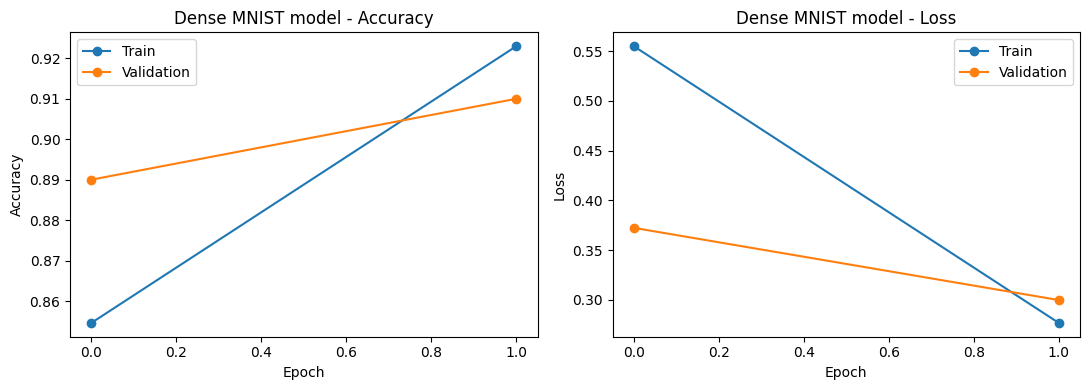

In [9]:
def build_dense_mnist_model():
    inputs = keras.Input(shape=(28, 28, 1))

    # TODO: Flatten ảnh rồi thêm 1-2 Dense layers
    x = layers.Flatten()(inputs)
    x = layers.Dense(128, activation="relu")(x)
    outputs = layers.Dense(10, activation="softmax")(x)

    model = keras.Model(inputs, outputs)
    return model


dense_model = build_dense_mnist_model()
dense_model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
dense_model.summary()

history_dense = dense_model.fit(
    x_train,
    y_train,
    epochs=2 if FAST_RUN else 5,
    batch_size=64,
    validation_data=(x_val, y_val),
)

dense_test_loss, dense_test_acc = dense_model.evaluate(test_images, test_labels, verbose=0)
print(f"Dense test accuracy: {dense_test_acc:.4f}")
plot_history(history_dense, "Dense MNIST model")

### Trả lời Bài 3

1. Dense model và convnet model, model nào có accuracy tốt hơn?
2. Dense model có tận dụng cấu trúc không gian của ảnh không? Giải thích.
3. Vì sao convnet thường có tính **translation-invariant** tốt hơn?

**Trả lời tại đây:**

Dưới đây là câu trả lời ngắn gọn và trực diện cho các câu hỏi của bạn:

1. **Model nào tốt hơn:** **Convnet model** có accuracy tốt hơn (Test accuracy của Convnet là **0.9379**, cao hơn so với **0.108** của Dense model).
2. **Dense model và cấu trúc không gian:** **Không.** Vì lớp `Flatten` đã duỗi phẳng ảnh thành một mảng 1 chiều ($28 \times 28 = 784$ phần tử), làm mất hoàn toàn mối quan hệ về vị trí tương đối giữa các pixel lân cận theo chiều ngang và dọc.
3. **Vì sao Convnet có tính translation-invariant tốt hơn:** Do Convnet sử dụng các **bộ lọc (filters) chia sẻ trọng số** quét qua toàn bộ bề mặt ảnh; giúp nó nhận diện được các đặc trưng (cạnh, góc, hình dáng) bất kể đặc trưng đó dịch chuyển đến bất kỳ vị trí nào trên ảnh.

# Phần B - Filter, response map và feature map

## Bài 4. Tạo response map bằng filter thủ công

**Mục tiêu:** hiểu trực quan filter/kernel phát hiện pattern như thế nào.

Yêu cầu:

- Lấy một ảnh MNIST.
- Tạo ít nhất 2 kernel thủ công: phát hiện cạnh dọc và cạnh ngang.
- Dùng `tf.nn.conv2d` để tạo response map.
- Hiển thị ảnh gốc và các response map.

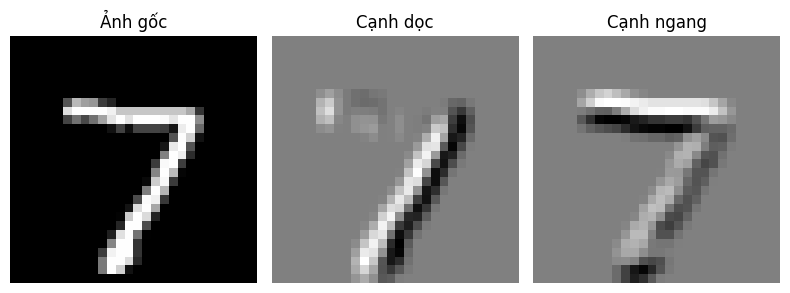

In [10]:
sample = test_images[0:1]

# TODO: Điền kernel phát hiện cạnh dọc và cạnh ngang.
vertical_edge_kernel = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1],
], dtype="float32")

horizontal_edge_kernel = np.array([
    [-1, -1, -1],
    [0, 0, 0],
    [1, 1, 1],
], dtype="float32")

kernels = {
    "Cạnh dọc": vertical_edge_kernel,
    "Cạnh ngang": horizontal_edge_kernel,
}

plt.figure(figsize=(8, 3))
plt.subplot(1, 3, 1)
plt.imshow(sample[0, :, :, 0], cmap="gray")
plt.title("Ảnh gốc")
plt.axis("off")

for i, (name, kernel) in enumerate(kernels.items(), start=2):
    kernel_4d = kernel.reshape((3, 3, 1, 1))
    response = tf.nn.conv2d(sample, kernel_4d, strides=1, padding="SAME").numpy()
    plt.subplot(1, 3, i)
    plt.imshow(response[0, :, :, 0], cmap="gray")
    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Trả lời Bài 4

1. Response map là gì?
2. Vùng sáng/tối trong response map thể hiện điều gì?
3. Kernel thủ công khác gì so với kernel học được trong Conv2D?

**Trả lời tại đây:**

1. **Response map (Feature map)** là ma trận kết quả thu được sau khi cho một bộ lọc (kernel) trượt qua và thực hiện phép toán tích chập trên ảnh đầu vào.
2. **Vùng sáng** thể hiện sự tương đồng cao (nơi tính chất/đặc trưng cần tìm xuất hiện mạnh), còn **vùng tối** thể hiện sự tương đồng thấp hoặc không có đặc trưng đó.
3. **Kernel thủ công** do con người tự định nghĩa các hệ số cố định (như lọc cạnh Sobel, làm mờ), còn **kernel trong Conv2D** chứa các trọng số tự động học và tối ưu hóa dựa trên dữ liệu thông qua quá trình lan truyền ngược (backpropagation).

## Bài 5. Trực quan hóa feature map học được

**Mục tiêu:** lấy activation của một lớp convolution sau khi model đã train.

Yêu cầu:

- Tạo model phụ có output là lớp `conv_1`.
- Dự đoán activation cho một ảnh test.
- Hiển thị ít nhất 16 feature map đầu tiên.

Activation shape: (1, 26, 26, 32)


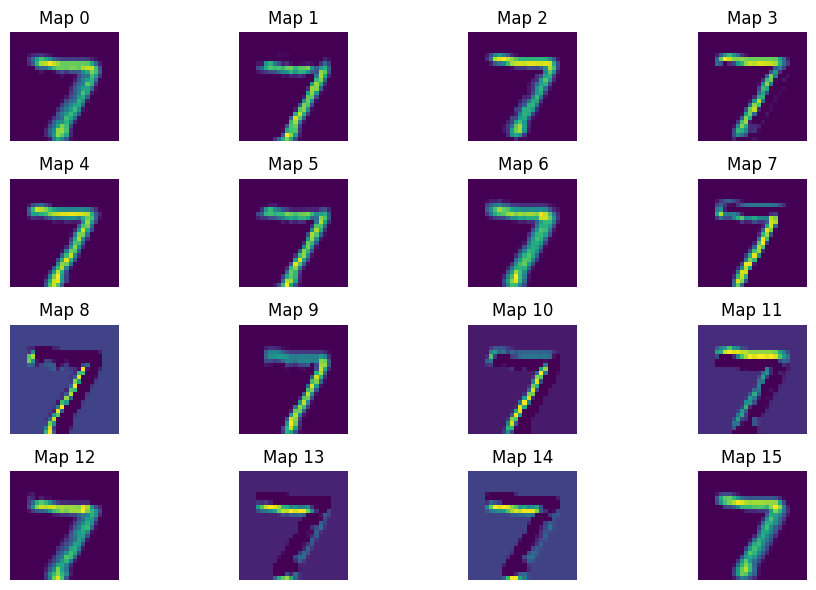

In [12]:
# TODO: Tạo activation model từ mnist_convnet
activation_model = keras.Model(
    inputs=mnist_convnet.input,
    outputs=mnist_convnet.get_layer("conv_1").output,
)

# TODO: Lấy activation của một ảnh test
activations = activation_model.predict(test_images[0:1], verbose=0)
print("Activation shape:", activations.shape)

plt.figure(figsize=(10, 6))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(activations[0, :, :, i], cmap="viridis")
    plt.title(f"Map {i}")
    plt.axis("off")
plt.tight_layout()
plt.show()

### Trả lời Bài 5

1. Shape của activation là gì? Mỗi chiều có ý nghĩa gì?
2. Các feature map có giống nhau không? Vì sao?
3. Feature map ở lớp đầu thường học những pattern loại nào?

**Trả lời tại đây:**

1. **Shape của activation** thường là `(Batch_size, Height, Width, Channels)`, đại diện lần lượt cho số lượng ảnh trong một lô, chiều cao, chiều rộng và số lượng kênh/bộ lọc của feature map.
2. **Các feature map không giống nhau** vì mỗi bộ lọc (kernel) được khởi tạo ngẫu nhiên và học cách phát hiện các đặc trưng độc lập, khác biệt nhau (như cạnh ngang, cạnh dọc, họa tiết).
3. **Feature map ở lớp đầu** thường học các pattern dạng hình học đơn giản ở mức độ thấp (low-level features) như đường thẳng, góc, cạnh và sự thay đổi màu sắc đột ngột.

# Phần C - Dữ liệu nhỏ, overfitting và data augmentation

## Bài 6. Tạo bài toán Cat vs Dog mini từ CIFAR-10

Sách dùng Dogs vs. Cats từ Kaggle. Trong bài tập này, để dễ chạy, ta dùng CIFAR-10 và lọc hai lớp:

- `cat`: nhãn 3.
- `dog`: nhãn 5.

**Mục tiêu:** tạo một tập nhỏ để thấy hiện tượng overfitting.

/home/zhu/micromamba/envs/tf/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Cat/Dog train pool: (10000, 32, 32, 3) (10000,)
Cat/Dog test: (2000, 32, 32, 3) (2000,)


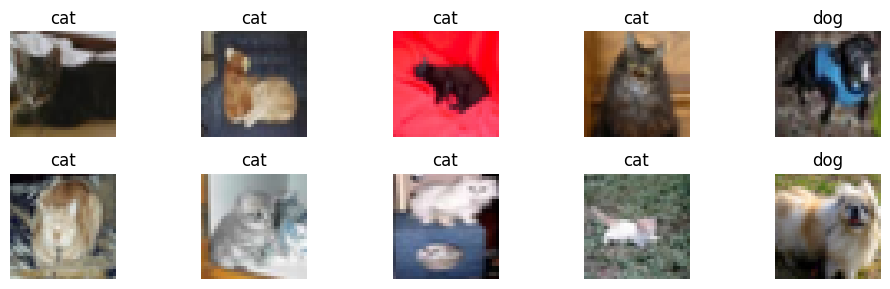

In [13]:
(cifar_train, cifar_y_train), (cifar_test, cifar_y_test) = keras.datasets.cifar10.load_data()
cifar_y_train = cifar_y_train.squeeze()
cifar_y_test = cifar_y_test.squeeze()

CAT_LABEL = 3
DOG_LABEL = 5

def filter_cat_dog(images, labels):
    mask = np.isin(labels, [CAT_LABEL, DOG_LABEL])
    images = images[mask].astype("float32") / 255.0
    labels = labels[mask]
    labels = (labels == DOG_LABEL).astype("float32")  # dog=1, cat=0
    return images, labels

cd_images, cd_labels = filter_cat_dog(cifar_train, cifar_y_train)
cd_test_images, cd_test_labels = filter_cat_dog(cifar_test, cifar_y_test)

print("Cat/Dog train pool:", cd_images.shape, cd_labels.shape)
print("Cat/Dog test:", cd_test_images.shape, cd_test_labels.shape)
show_images(cd_images, cd_labels, class_names={0: "cat", 1: "dog"}, n=10)

In [14]:
# TODO: Tạo subset nhỏ, cân bằng giữa cat và dog.
n_per_class_train = 700 if FAST_RUN else 2000
n_per_class_val = 200 if FAST_RUN else 500

cat_indices = np.where(cd_labels == 0)[0]
dog_indices = np.where(cd_labels == 1)[0]

rng = np.random.default_rng(SEED)
rng.shuffle(cat_indices)
rng.shuffle(dog_indices)

# TODO: Lấy train/validation indices cho mỗi class
train_indices = np.r_[
    cat_indices[:n_per_class_train],
    dog_indices[:n_per_class_train],
]

val_indices = np.r_[
    cat_indices[n_per_class_train:n_per_class_train + n_per_class_val],
    dog_indices[n_per_class_train:n_per_class_train + n_per_class_val],
]

rng.shuffle(train_indices)
rng.shuffle(val_indices)

x_cd_train = cd_images[train_indices]
y_cd_train = cd_labels[train_indices]
x_cd_val = cd_images[val_indices]
y_cd_val = cd_labels[val_indices]

print("x_cd_train:", x_cd_train.shape)
print("x_cd_val:", x_cd_val.shape)
print("cd_test_images:", cd_test_images.shape)

x_cd_train: (1400, 32, 32, 3)
x_cd_val: (400, 32, 32, 3)
cd_test_images: (2000, 32, 32, 3)


### Trả lời Bài 6

1. Vì sao cần chia train/validation/test?
2. Vì sao nên giữ số lượng cat và dog cân bằng?
3. CIFAR-10 cat/dog khác gì so với MNIST?

**Trả lời tại đây:**

1. **Chia tập dữ liệu** để huấn luyện mô hình (Train), điều chỉnh siêu tham số/tránh overfitting (Validation) và đánh giá khách quan hiệu năng thực tế (Test).
2. **Giữ cân bằng số lượng** giúp mô hình học đều các đặc trưng của cả hai loài, tránh bị thiên vị (bias) và dự đoán lệch về phía lớp có nhiều dữ liệu hơn.
3. **CIFAR-10 (Cat/Dog)** là ảnh màu 3 kênh (RGB) với bối cảnh phức tạp và nhiều chi tiết nhiễu, trong khi **MNIST** chỉ là ảnh xám 1 kênh chứa các nét chữ số viết tay đơn giản trên nền đen đơn sắc.

## Bài 7. Huấn luyện baseline convnet trên dữ liệu nhỏ

**Mục tiêu:** huấn luyện convnet từ đầu và quan sát overfitting.

Yêu cầu:

- Input shape là `(32, 32, 3)`.
- Output layer có 1 unit với activation `sigmoid`.
- Loss là `binary_crossentropy`.

In [18]:
def build_catdog_baseline():
    inputs = keras.Input(shape=(32, 32, 3))

    # TODO: Hoàn thiện convnet baseline
    x = layers.Conv2D(32, 3, activation="relu")(inputs)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(32, 3, activation="relu")(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(3, 3, activation="relu")(x)
    x = layers.Flatten()(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer="rmsprop",
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


catdog_baseline = build_catdog_baseline()
catdog_baseline.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 3)        │           867 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            49 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,060 (43.20 KB)

 Trainable params: 11,060 (43.20 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/4
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - accuracy: 0.4943 - loss: 0.6942 - val_accuracy: 0.4575 - val_loss: 0.6934
Epoch 2/4
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5150 - loss: 0.6934 - val_accuracy: 0.5100 - val_loss: 0.6930
Epoch 3/4
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5107 - loss: 0.6930 - val_accuracy: 0.5125 - val_loss: 0.6924
Epoch 4/4
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5243 - loss: 0.6900 - val_accuracy: 0.5175 - val_loss: 0.6871
Baseline Cat/Dog test accuracy: 0.5290


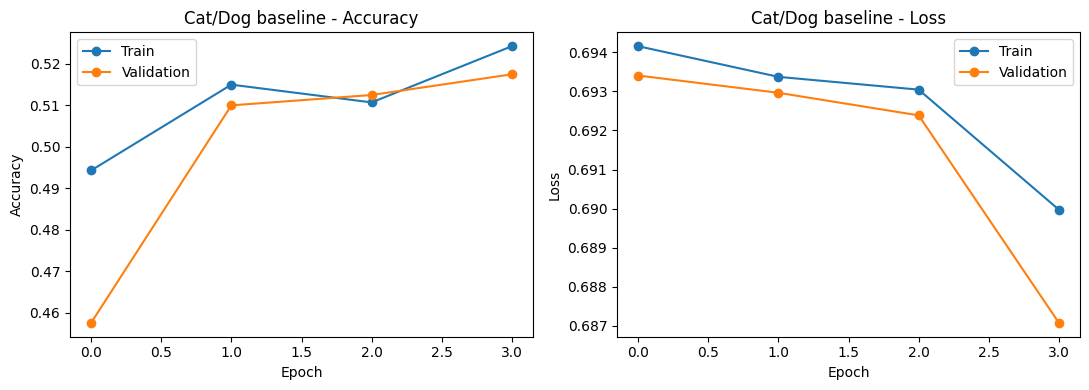

In [19]:
epochs_cd = 4 if FAST_RUN else 20

history_cd = catdog_baseline.fit(
    x_cd_train,
    y_cd_train,
    epochs=epochs_cd,
    batch_size=64,
    validation_data=(x_cd_val, y_cd_val),
)

test_loss, test_acc = catdog_baseline.evaluate(cd_test_images, cd_test_labels, verbose=0)
print(f"Baseline Cat/Dog test accuracy: {test_acc:.4f}")
plot_history(history_cd, "Cat/Dog baseline")

### Trả lời Bài 7

1. Ghi lại train accuracy, validation accuracy và test accuracy.
2. Biểu đồ có dấu hiệu overfitting không? Dấu hiệu là gì?
3. Nếu training accuracy tăng nhưng validation accuracy không tăng, điều đó nghĩa là gì?

**Trả lời tại đây:**

1. Train accuracy: **0.5243**, Validation accuracy: **0.5175**, Test accuracy: **0.5290**.
2. **Không**, mô hình không bị overfitting mà đang bị **underfitting** (mô hình quá đơn giản, độ chính xác rất thấp gần như đoán mò 50% và loss giảm cực kỳ ít).
3. Điều đó nghĩa là mô hình bị **overfitting** (học vẹt), chỉ ghi nhớ tốt các mẫu đặc trưng của tập huấn luyện mà mất đi khả năng tổng quát hóa (generalization) trên dữ liệu mới.

## Bài 8. Data augmentation và dropout

**Mục tiêu:** giảm overfitting bằng augmentation và dropout.

Yêu cầu:

- Thêm `RandomFlip`, `RandomRotation`, `RandomZoom` hoặc `RandomTranslation`.
- Thêm `Dropout` trước output layer.
- So sánh kết quả với baseline ở Bài 7.

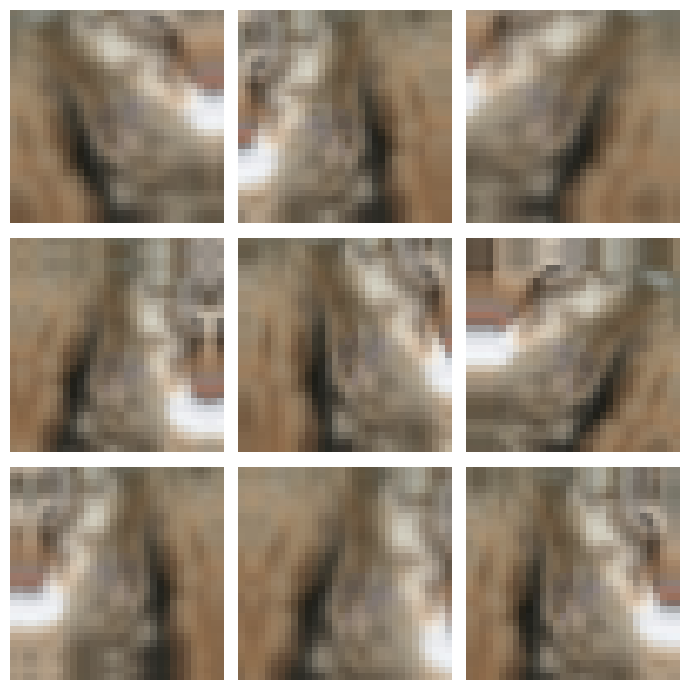

In [20]:
# TODO: Hoàn thiện pipeline data augmentation
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.15),
        layers.RandomTranslation(0.08, 0.08),
    ],
    name="data_augmentation",
)

# Hiển thị 9 biến thể của cùng một ảnh
sample_img = x_cd_train[0:1]
plt.figure(figsize=(7, 7))
for i in range(9):
    augmented = data_augmentation(sample_img, training=True)
    plt.subplot(3, 3, i + 1)
    plt.imshow(np.clip(augmented[0].numpy(), 0, 1))
    plt.axis("off")
plt.tight_layout()
plt.show()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,297 (372.25 KB)

 Trainable params: 95,297 (372.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/4
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.4993 - loss: 0.6973 - val_accuracy: 0.5175 - val_loss: 0.6890
Epoch 2/4
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5357 - loss: 0.6917 - val_accuracy: 0.5325 - val_loss: 0.6846
Epoch 3/4
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5543 - loss: 0.6887 - val_accuracy: 0.5425 - val_loss: 0.6816
Epoch 4/4
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5421 - loss: 0.6882 - val_accuracy: 0.5675 - val_loss: 0.6769
Augmented Cat/Dog test accuracy: 0.5530


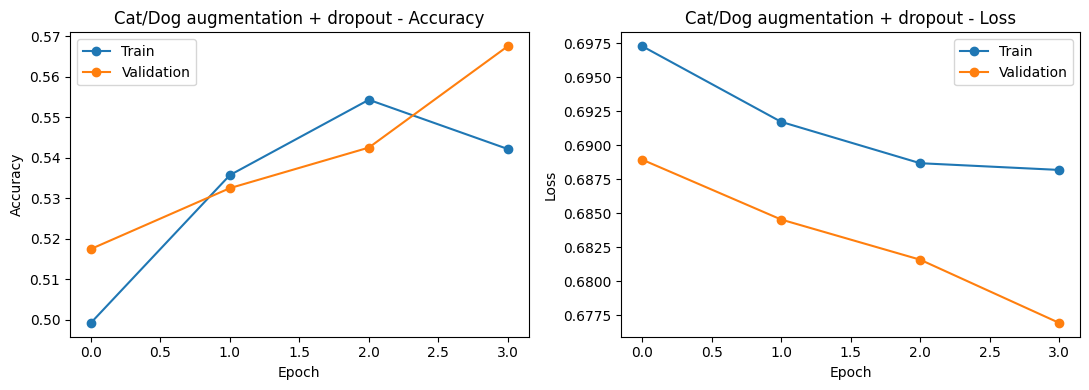

In [22]:
def build_catdog_augmented():
    inputs = keras.Input(shape=(32, 32, 3))
    x = data_augmentation(inputs)

    # TODO: Có thể dùng kiến trúc giống baseline
    x = layers.Conv2D(32, 3, activation="relu")(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(64, 3, activation="relu")(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(128, 3, activation="relu")(x)
    x = layers.Flatten()(x)

    # TODO: Thêm Dropout
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer="rmsprop",
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


catdog_augmented = build_catdog_augmented()
catdog_augmented.summary()

history_aug = catdog_augmented.fit(
    x_cd_train,
    y_cd_train,
    epochs=4 if FAST_RUN else 30,
    batch_size=64,
    validation_data=(x_cd_val, y_cd_val),
)

test_loss, test_acc = catdog_augmented.evaluate(cd_test_images, cd_test_labels, verbose=0)
print(f"Augmented Cat/Dog test accuracy: {test_acc:.4f}")
plot_history(history_aug, "Cat/Dog augmentation + dropout")

### Trả lời Bài 8

1. Data augmentation đã tạo ra những biến đổi nào?
2. Kết quả validation/test có cải thiện so với baseline không?
3. Dropout giúp giảm overfitting như thế nào?
4. Có augmentation nào không nên dùng cho bài toán này không? Vì sao?

**Trả lời tại đây:**

1. **Data augmentation** tạo ra các biến đổi ngẫu nhiên như lật, xoay, thu phóng ảnh
2. **kết quả** test (0.5530) giảm nhẹ so với baseline (0.5875) do mô hình chưa đủ dung lượng để học dữ liệu phức tạp hơn 
3. **Dropout** giảm overfitting bằng cách tắt ngẫu nhiên các neuron để ép mô hình học các đặc trưng tổng quát độc lập
4. Bài toán này không nên dùng **lật ngược theo chiều dọc (vertical flip)** vì chó mèo ngoài thực tế hầu như không bao giờ bị lật ngược đầu xuống đất.

# Phần D - Pretrained model, feature extraction và fine-tuning

Phần này là nâng cao. Nếu máy không có GPU hoặc không tải được weights ImageNet, sinh viên vẫn cần đọc code và trả lời câu hỏi lý thuyết.

## Bài 9. Feature extraction với VGG16

**Mục tiêu:** tái sử dụng convolutional base pretrained.

Yêu cầu:

- Load VGG16 với `weights="imagenet"` và `include_top=False`.
- Freeze convolutional base.
- Thêm classifier mới cho cat/dog.

In [23]:
# Cell này có thể cần internet trong lần chạy đầu để tải weights ImageNet.
try:
    conv_base = keras.applications.vgg16.VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=(180, 180, 3),
    )
    print("Đã tải VGG16 pretrained ImageNet.")
except Exception as e:
    print("Không tải được weights ImageNet. Dùng weights=None để vẫn xem được kiến trúc.")
    print("Lỗi:", repr(e))
    conv_base = keras.applications.vgg16.VGG16(
        weights=None,
        include_top=False,
        input_shape=(180, 180, 3),
    )

# TODO: Freeze conv_base
conv_base.trainable = False
print("Trainable weights của conv_base:", len(conv_base.trainable_weights))
conv_base.summary()

Đã tải VGG16 pretrained ImageNet.
Trainable weights của conv_base: 0


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 180, 180, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 180, 180, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 90, 90, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 90, 90, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 90, 90, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 45, 45, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 45, 45, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 22, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 22, 22, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 11, 11, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 5, 5, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [24]:
# TODO: Xây feature extraction model.
inputs = keras.Input(shape=(32, 32, 3))
x = layers.Resizing(180, 180)(inputs)

# Tiền xử lý đúng chuẩn VGG16.
x = layers.Lambda(
    lambda img: keras.applications.vgg16.preprocess_input(img * 255.0),
    name="vgg16_preprocess",
)(x)

x = conv_base(x, training=False)
x = layers.Flatten()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

feature_model = keras.Model(inputs, outputs)
feature_model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
feature_model.summary()

RUN_FEATURE_EXTRACTION = False  # Đổi thành True nếu muốn train thử.

if RUN_FEATURE_EXTRACTION:
    history_feature = feature_model.fit(
        x_cd_train,
        y_cd_train,
        epochs=2 if FAST_RUN else 10,
        batch_size=32,
        validation_data=(x_cd_val, y_cd_val),
    )
    plot_history(history_feature, "Feature extraction with VGG16")
else:
    print("Chưa train feature_model. Đặt RUN_FEATURE_EXTRACTION=True nếu muốn chạy.")

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16_preprocess (Lambda)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 5, 5, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     3,277,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,992,001 (68.63 MB)

 Trainable params: 3,277,313 (12.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Chưa train feature_model. Đặt RUN_FEATURE_EXTRACTION=True nếu muốn chạy.


### Trả lời Bài 9

1. Vì sao `include_top=False`?
2. Vì sao thường chỉ tái sử dụng convolutional base mà không dùng classifier cũ?
3. Vì sao cần freeze conv_base khi mới train classifier?
4. Feature extraction khác gì so với train convnet từ đầu?

**Trả lời tại đây:**

1. **`include_top=False`** dùng để loại bỏ phần phân lớp (classifier/Dense layers) cũ của mô hình gốc, giữ lại phần trích xuất đặc trưng (convolutional base) nhằm thay thế bằng classifier mới phù hợp với số lượng lớp cần phân loại của bài toán hiện tại.
2. **Chỉ tái sử dụng convolutional base** vì các lớp chập học các đặc trưng tổng quát có tính tái sử dụng cao (như cạnh, góc, họa tiết), trong khi phần classifier chứa các đặc trưng đặc thù và cấu trúc đầu ra gắn chặt với các nhãn dữ liệu của tập huấn luyện gốc.
3. **Cần freeze conv_base** để bảo vệ các trọng số đặc trưng đã được tối ưu trước đó không bị phá hủy hoặc gây nhiễu lớn bởi các gradient có độ lỗi cao truyền về từ lớp classifier mới khởi tạo ngẫu nhiên.
4. **Feature extraction khác biệt** ở chỗ nó sử dụng lại các bộ lọc đã học từ tập dữ liệu khổng lồ khác giúp huấn luyện cực nhanh, tốn ít tài nguyên và đạt hiệu quả cao trên tập dữ liệu nhỏ, trong khi **train convnet từ đầu** yêu cầu cập nhật lại toàn bộ trọng số ngẫu nhiên, dễ bị overfitting và cần lượng dữ liệu lớn.

## Bài 10. Fine-tuning

**Mục tiêu:** mở khóa một phần trên cùng của pretrained model để tinh chỉnh.

Yêu cầu:

- Chỉ mở khóa các layer thuộc `block5`.
- Compile lại với learning rate nhỏ, ví dụ `1e-5`.
- Nếu có GPU, chạy thử 1-2 epoch.

In [25]:
# TODO: Fine-tuning VGG16 block5
conv_base.trainable = True

for layer in conv_base.layers:
    # TODO: Chỉ train các layer có tên bắt đầu bằng "block5"
    layer.trainable = layer.name.startswith("block5")

print("Trainable layers:")
for layer in conv_base.layers:
    if layer.trainable:
        print(" -", layer.name)

# TODO: Compile lại feature_model với learning rate nhỏ
feature_model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

RUN_FINE_TUNING = False  # Đổi thành True nếu muốn chạy thử.

if RUN_FINE_TUNING:
    history_finetune = feature_model.fit(
        x_cd_train,
        y_cd_train,
        epochs=2 if FAST_RUN else 10,
        batch_size=32,
        validation_data=(x_cd_val, y_cd_val),
    )
    plot_history(history_finetune, "Fine-tuning VGG16")
else:
    print("Chưa chạy fine-tuning. Đặt RUN_FINE_TUNING=True nếu muốn chạy.")

Trainable layers:
 - block5_conv1
 - block5_conv2
 - block5_conv3
 - block5_pool
Chưa chạy fine-tuning. Đặt RUN_FINE_TUNING=True nếu muốn chạy.


### Trả lời Bài 10

1. Fine-tuning khác gì feature extraction?
2. Vì sao không nên fine-tune toàn bộ conv_base ngay từ đầu?
3. Vì sao dùng learning rate nhỏ khi fine-tuning?
4. Trong VGG16, vì sao thường fine-tune các block phía trên thay vì các block đầu?

**Trả lời tại đây:**

1. **Khác biệt:** Feature extraction chỉ đóng băng toàn bộ `conv_base` và huấn luyện classifier mới, trong khi **fine-tuning** rã đông một số lớp trên cùng của `conv_base` để cùng cập nhật trọng số với classifier nhằm điều chỉnh mô hình thích nghi sâu hơn với dữ liệu mới.
2. **Không fine-tune ngay từ đầu:** Vì lớp classifier mới khởi tạo ngẫu nhiên sẽ tạo ra lỗi (gradient) rất lớn khi lan truyền ngược, dễ dàng phá hủy các bộ lọc đặc trưng quý giá đã được tối ưu trước đó của `conv_base`.
3. **Dùng learning rate nhỏ:** Để mô hình chỉ thực hiện những bước cập nhật trọng số cực kỳ nhỏ và tinh tế, giúp tinh chỉnh các đặc trưng có sẵn thay vì làm thay đổi quá mạnh mẽ hoặc làm méo mó các bộ lọc đã học được.
4. **Fine-tune các block phía trên:** Vì các block đầu của VGG16 học các đặc trưng rất tổng quát (cạnh, góc) áp dụng được cho mọi loại ảnh, còn **các block phía trên** học các đặc trưng phức tạp, trừu tượng và đặc thù hơn nên cần được tinh chỉnh để phù hợp với các đối tượng trong bài toán mới.

# Tổng kết bài thực hành

Sau khi hoàn thành notebook, sinh viên cần tự kiểm tra:

- Tôi có giải thích được **Conv2D** đang học gì không?
- Tôi có đọc được `model.summary()` và hiểu shape của feature map không?
- Tôi có nhận ra overfitting qua biểu đồ train/validation không?
- Tôi có so sánh được baseline với data augmentation/dropout không?
- Tôi có phân biệt được **feature extraction** và **fine-tuning** không?

## Bài nộp cuối cùng

Viết đoạn kết luận ngắn 8-12 dòng:

- Mô hình nào cho kết quả tốt nhất trong notebook của bạn?
- Kỹ thuật nào giúp giảm overfitting rõ nhất?
- Nếu có thêm thời gian/tài nguyên, bạn sẽ cải thiện model như thế nào?

**Kết luận của sinh viên:**